In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# ====================================
# Module 1: GENRATIG SYNTHETIC DATA
# ====================================

# Adding seed to get the same data eveytime
np.random.seed(56)

#Defining the dimension of the training data set
m = 100 # Number of training samples (rows) 
n = 10  # Number of features (Columns)

# Genrating feature matrix X 
X = np.random.uniform(-3, 3, (m,n)) #creates 100x10 matrix with random float values ranging from -3.0 to 3.0
print(f"Dimension of Matrix X : {X.shape}") 

# Genrating the non-linear target vector y
# Let's inject the non-linear patterns into few features

""" 
Feature 0 - sine wave
Feature 1 - Sqaured funtion
Feature 2 and 3 - interating with each other in cosin wave 

The remaining features acts like complex basline enviroment
"""

non_linear_trend = ( np.sin(X[:,0]) + 0.5 * np.square(X[:,1]) - 
                    np.cos(X[:,2] * X[:,3]) + 0.1 * np.sum(X[:,4:], axis = 1)
                    )

print(f"Dimension of non-linear trend : {non_linear_trend.shape}")

# Adding Gaussian noise (epsilon) to stimulate the real world imperfections
noise = np.random.normal(0, 0.2, size = len(X)) # Mean = 0, standard deviation = 0.2

# Combining the non-linear trend + noise to genrate the target Y and reshape into column vector (100,1)

y = ( non_linear_trend+ noise ).reshape(-1,1)

print(f"Dimension of target Y : {y.shape}") 



Dimension of Matrix X : (100, 10)
Dimension of non-linear trend : (100,)
Dimension of target Y : (100, 1)


In [3]:
# ===================================
#  MODULE 2: NORMALIZATION OF X AND Y
# ====================================

#Min-Max Scaling (Normalization)

#calulating the mean and standard deviavtion along each column(axis = 0)
X_mean = np.mean(X, axis = 0)
X_std = np.std(X, axis = 0)


#protect against divion by zero in case a feature has zero varience 
X_std[X_std == 0.0] = 1.0 

#Standerdizing the traing data set
X_train =(X - X_mean)/X_std 

print(f"Training Matrix mean after scaling (Should be approx to 0) : {np.mean(X_train):.4f}")
print(f"Training Matrix mean after scaling (Should be approx to 1) : {np.std(X_train):.4f}")


Training Matrix mean after scaling (Should be approx to 0) : -0.0000
Training Matrix mean after scaling (Should be approx to 1) : 1.0000


In [4]:

# =====================================================================
# MODULE 3: CONVERT TO PANDAS DATAFRAME & CREATE GROUPS
# =====================================================================

# Creating a DataFrame with structured column names
df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(n)])
df['target_y'] = y

# Creating a binary categorical splitter variable 
# Group 0: Feature 0 is negative | Group 1: Feature 0 is positive
df['group'] = (df['feature_0'] > 0).astype(int)



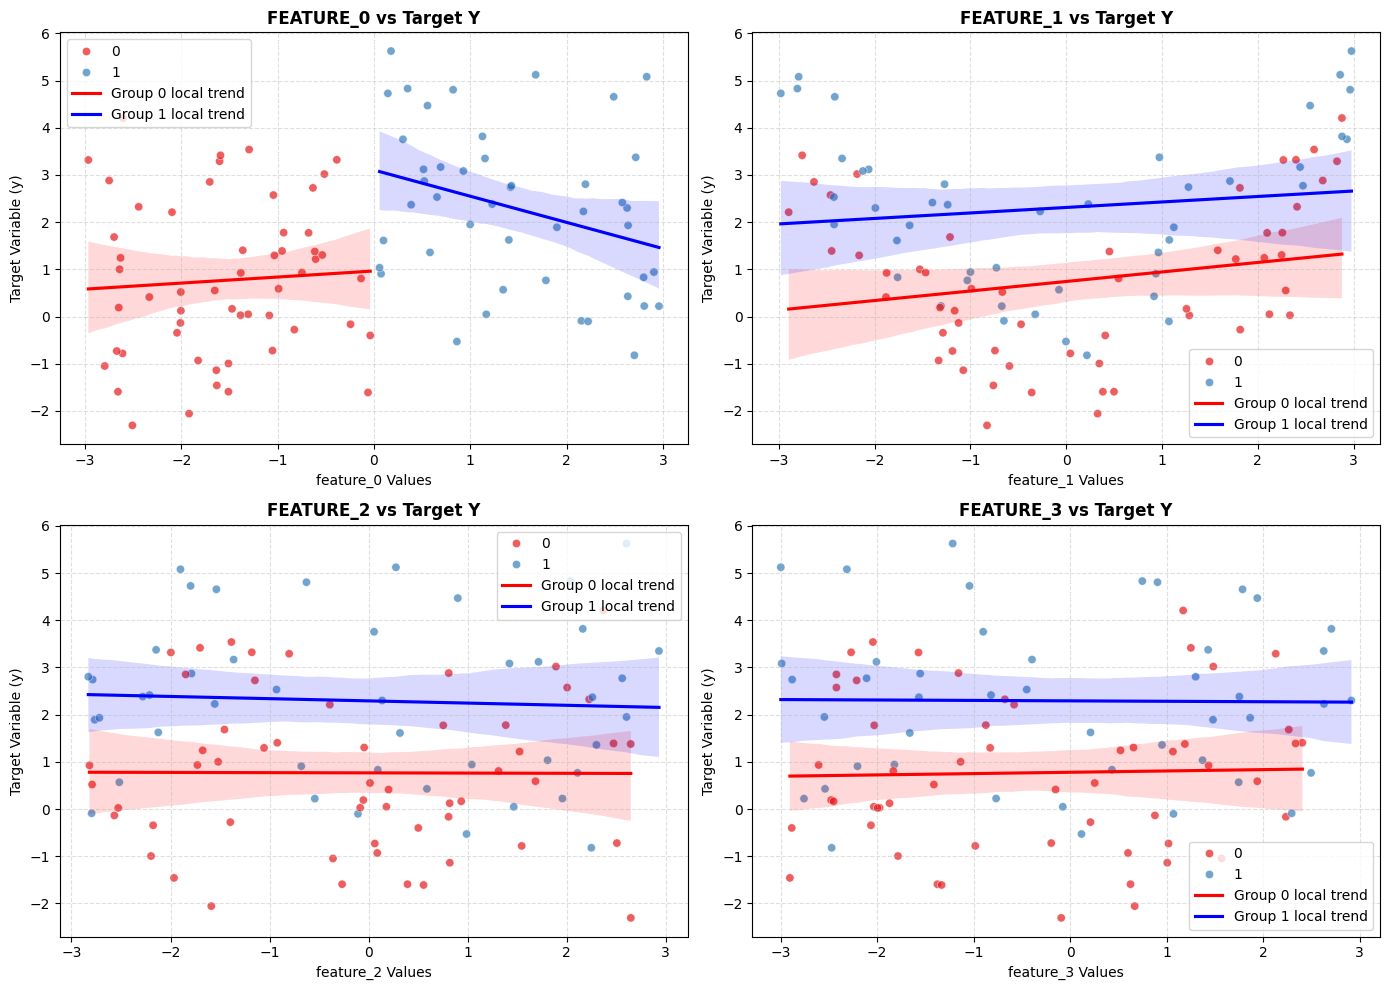

In [5]:
# =====================================================================
# MODULE 4: VISUALIZATION MODULE (Matching Your Custom Formatting)
# =====================================================================

# Select the first 4 features to inspect their geometric patterns
selected_features = ['feature_0', 'feature_1', 'feature_2', 'feature_3']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()  # Flatten the 2D grid layout into 1D for easy iteration

for idx, col in enumerate(selected_features):
    
    # Create the scatter plot layered by our categorical grouping
    sns.scatterplot(data=df, x=col, y='target_y', hue='group', 
                    alpha=0.7, ax=axes[idx], palette='Set1')
    
    # Layer Group 0 Trend Line (Red)
    sns.regplot(data=df[df['group'] == 0], x=col, y='target_y', 
                scatter=False, color='red', ax=axes[idx], label='Group 0 local trend')
    
    # Layer Group 1 Trend Line (Blue)
    sns.regplot(data=df[df['group'] == 1], x=col, y='target_y', 
                scatter=False, color='blue', ax=axes[idx], label='Group 1 local trend')
    
    # Graph titles and custom Y-Axis labels
    axes[idx].set_title(f'{col.upper()} vs Target Y', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Target Variable (y)')
    axes[idx].set_xlabel(f'{col} Values')
    axes[idx].grid(True, linestyle='--', alpha=0.4)
    axes[idx].legend()

plt.tight_layout()
plt.show()


In [14]:
def lwlr_prediction(X_train, y_train, x_qurey, tau, X_mean=None, X_std=None):
    
    m,n = X_train.shape
    
    #scaling the X_qurey 
    if X_mean is not None and X_std is not None :
        x_query_scaled = (x_qurey - X_mean)/X_std
        
    else:
        x_query_scaled = x_query     
    
    #prepairing Design Matrix
    X_design = np.hstack([np.ones((m,1)) , X_train])
    x_query_padded = np.insert(x_query_scaled,0,1)
    
    #vectorised squared Euclidean distance computation
    sq_dist = np.sum((X_train - x_query_scaled.reshape(1, -1))** 2, axis=1)
    
    #Calulate the weights and populating it into diagonal
    weights = np.exp(-sq_dist / (2*(tau ** 2)))
    
    W = np.diag(weights)
    
    #Construct the localized normal equation
    A = X_design.T @ W @ X_design
    B = X_design.T @ W @ y_train
    
    #Calculating the hyperparemeter use (pseudo - inverse)
    theta = np.linalg.pinv(A) @ B
    
    y_prediction = x_query_padded @ theta  
    
    return y_prediction

        

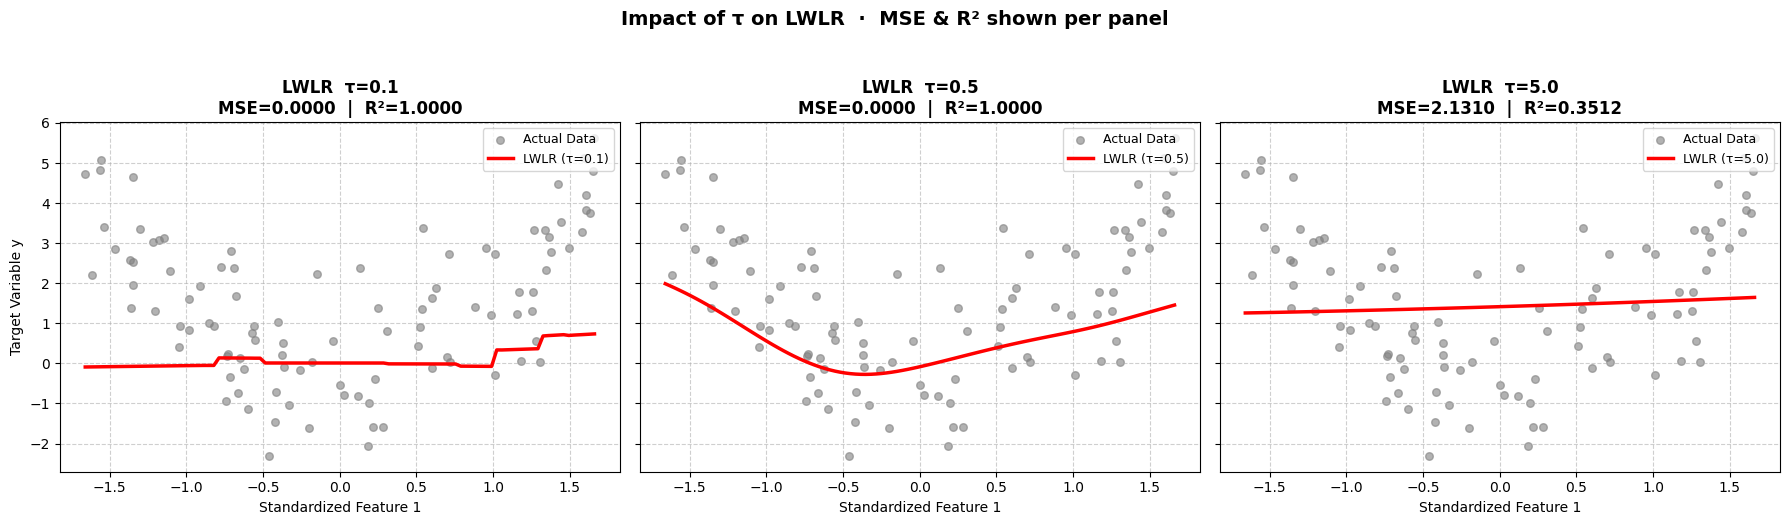

In [17]:
tau_values = [0.1, 0.5, 5.0]
feat_min, feat_max = X_train[:, 1].min(), X_train[:, 1].max()
grid_points = np.linspace(feat_min, feat_max, 100)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
error_records = []

for idx, tau in enumerate(tau_values):
    # Grid predictions for curve
    predictions = []
    for q_val in grid_points:
        x_query = np.zeros(n)
        x_query[1] = q_val  # FIX: always vary Feature 1
        pred = lwlr_prediction(X_train, y, x_query, tau=tau, X_mean=X_mean, X_std=X_std)
        predictions.append(float(np.squeeze(pred)))

    # Training-set predictions for error metrics
    y_pred_train = []
    for i in range(m):
        pred_i = lwlr_prediction(X_train, y, X[i], tau=tau, X_mean=X_mean, X_std=X_std)
        y_pred_train.append(float(np.squeeze(pred_i)))

    y_pred_train = np.array(y_pred_train).reshape(-1, 1)
    mse  = mean_squared_error(y, y_pred_train)
    rmse = np.sqrt(mse)
    r2   = r2_score(y, y_pred_train)
    error_records.append({'tau': tau, 'MSE': mse, 'RMSE': rmse, 'R2': r2})

    axes[idx].scatter(X_train[:, 1], y, color='gray', alpha=0.6,
                      label='Actual Data', s=30)
    axes[idx].plot(grid_points, predictions, color='red', linewidth=2.5,
                   label=f'LWLR (τ={tau})')
    axes[idx].set_title(
        f'LWLR  τ={tau}\nMSE={mse:.4f}  |  R²={r2:.4f}',
        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Standardized Feature 1')
    if idx == 0:
        axes[idx].set_ylabel('Target Variable y')
    axes[idx].grid(True, linestyle='--', alpha=0.6)
    axes[idx].legend(loc='upper right', fontsize=9)

plt.suptitle('Impact of τ on LWLR  ·  MSE & R² shown per panel',
             fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()     

In [18]:
err_df = pd.DataFrame(error_records)

def regime(r2):
    if r2 > 0.999:
        return ' OVERFITTING  – low τ memorises noise'
    elif r2 < 0.60:
        return 'UNDERFITTING – high τ ignores local patterns'
    else:
        return ' GOOD FIT'

err_df['Diagnosis'] = err_df['R2'].apply(regime)
print('=' * 65)
print('          LWLR Error Analysis Summary')
print('=' * 65)
print(err_df.to_string(index=False))
print()
print('Interpretation:')
print('  τ=0.1  → extremely narrow kernel → each prediction uses only')
print('           its 1-2 nearest neighbours → R²≈1 on TRAIN but will')
print('           collapse on unseen data  (OVERFITTING)')
print('  τ=0.5  → still very tight → R²≈1 train, likely overfit')
print('  τ=5.0  → wide kernel averages almost all 100 points equally')
print('           → essentially global regression → misses local curves')
print('           (UNDERFITTING, R²=0.35)')

          LWLR Error Analysis Summary
 tau          MSE         RMSE       R2                                    Diagnosis
 0.1 3.301123e-31 5.745540e-16 1.000000         OVERFITTING  – low τ memorises noise
 0.5 3.546457e-06 1.883204e-03 0.999999         OVERFITTING  – low τ memorises noise
 5.0 2.130975e+00 1.459786e+00 0.351214 UNDERFITTING – high τ ignores local patterns

Interpretation:
  τ=0.1  → extremely narrow kernel → each prediction uses only
           its 1-2 nearest neighbours → R²≈1 on TRAIN but will
           collapse on unseen data  (OVERFITTING)
  τ=0.5  → still very tight → R²≈1 train, likely overfit
  τ=5.0  → wide kernel averages almost all 100 points equally
           → essentially global regression → misses local curves
           (UNDERFITTING, R²=0.35)


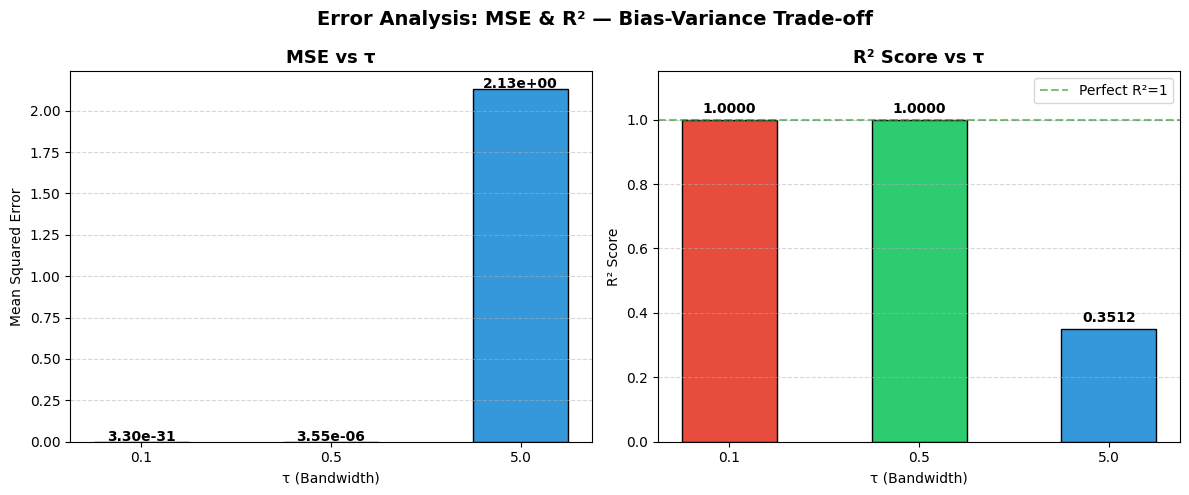

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tau_labels = [str(t) for t in err_df['tau']]
colors = ['#e74c3c', '#2ecc71', '#3498db']

# MSE bar
axes[0].bar(tau_labels, err_df['MSE'], color=colors, edgecolor='black', width=0.5)
axes[0].set_title('MSE vs τ', fontsize=13, fontweight='bold')
axes[0].set_xlabel('τ (Bandwidth)')
axes[0].set_ylabel('Mean Squared Error')
for i, v in enumerate(err_df['MSE']):
    axes[0].text(i, v + 0.005, f'{v:.2e}', ha='center', fontsize=10, fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# R² bar
axes[1].bar(tau_labels, err_df['R2'], color=colors, edgecolor='black', width=0.5)
axes[1].set_title('R² Score vs τ', fontsize=13, fontweight='bold')
axes[1].set_xlabel('τ (Bandwidth)')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, 1.15)
for i, v in enumerate(err_df['R2']):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[1].axhline(y=1.0, color='green', linestyle='--', alpha=0.5, label='Perfect R²=1')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Error Analysis: MSE & R² — Bias-Variance Trade-off',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()